Data Loading and Preprocessing

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

In [2]:
data=fetch_california_housing()
df=pd.DataFrame(data.data, columns=data.feature_names)
df["MedHouseVal"]=data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [5]:
df.duplicated().sum()

np.int64(0)

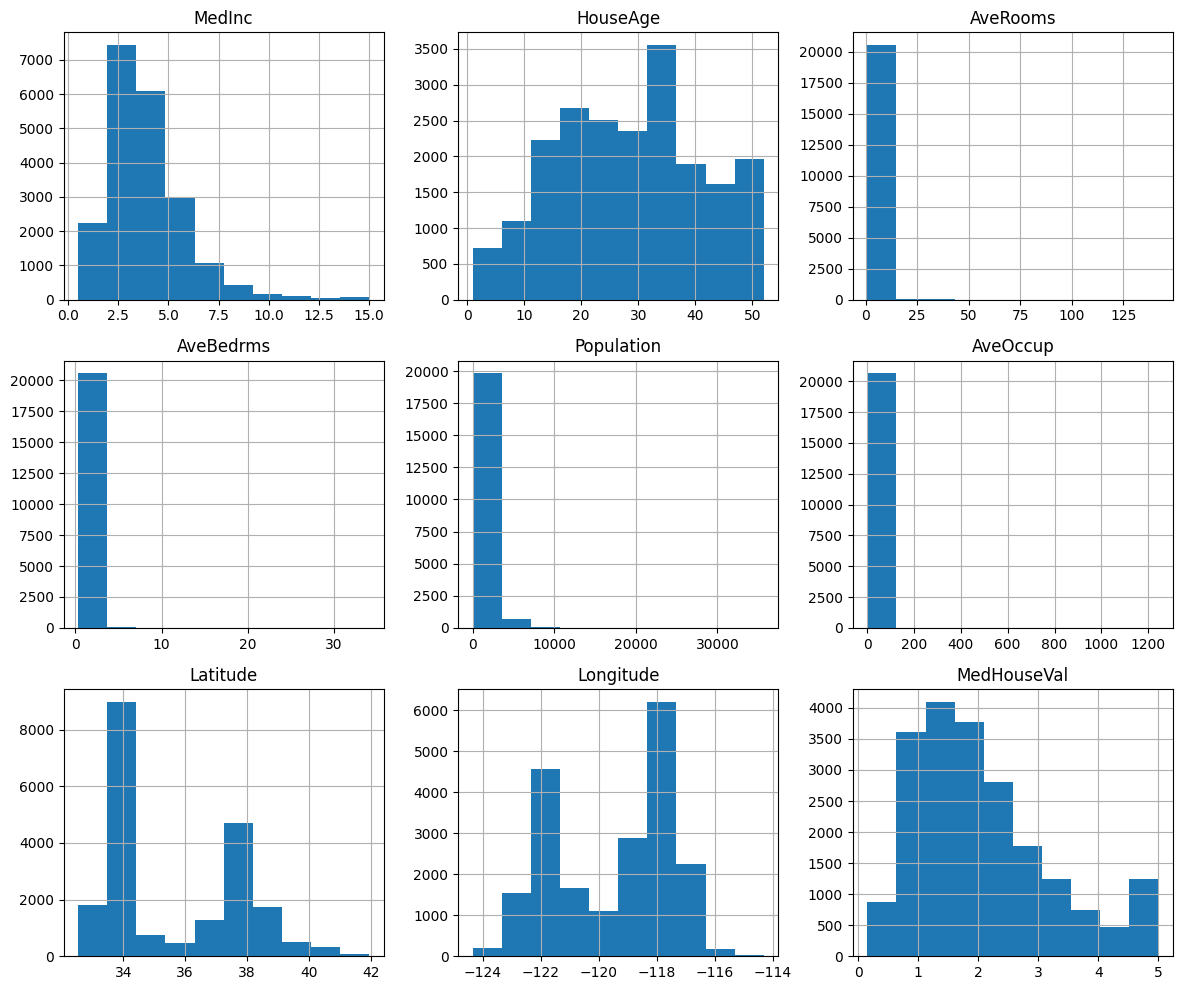

In [6]:
import matplotlib.pyplot as plt

df.hist(figsize=(12, 10))

plt.tight_layout()
plt.show()

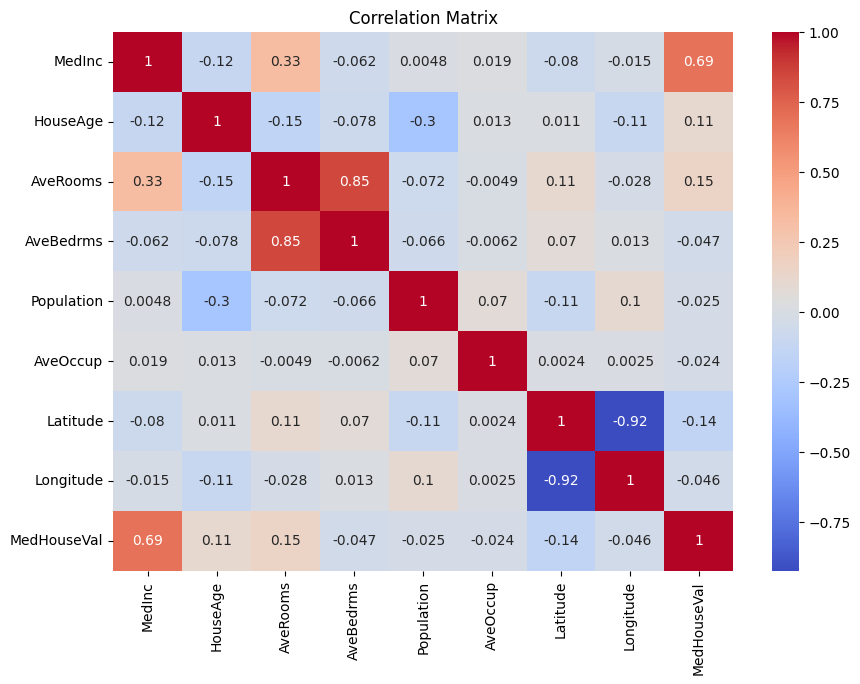

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

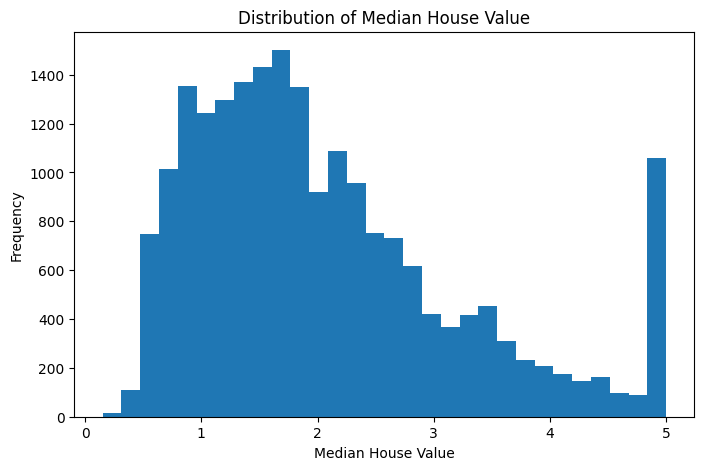

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["MedHouseVal"], bins=30)

plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.title("Distribution of Median House Value")

plt.show()

In [9]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (20640, 8)
Target: (20640,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 8)
Testing data: (4128, 8)


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Linear Regression

Linear Regression models the relationship between the input features and
the target variable using a linear equation.

It is suitable as a simple baseline model for the California Housing dataset.

In [12]:
from sklearn.linear_model import LinearRegression

linear_model=LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_pred=linear_model.predict(X_test_scaled)

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

linear_mse=mean_squared_error(y_test, linear_pred)
linear_mae=mean_absolute_error(y_test, linear_pred)
linear_r2=r2_score(y_test, linear_pred)

print("Linear Regression")
print("MSE:", linear_mse)
print("MAE:", linear_mae)
print("R²:", linear_r2)

Linear Regression
MSE: 0.5558915986952442
MAE: 0.5332001304956565
R²: 0.575787706032451


### Decision Tree Regressor

A Decision Tree Regressor splits the data into smaller groups using
decision rules and predicts a value for each final region.

It can capture non-linear relationships in the California Housing dataset.

In [14]:
from sklearn.tree import DecisionTreeRegressor

tree_model=DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)
tree_pred=tree_model.predict(X_test)

In [15]:
tree_mse = mean_squared_error(y_test, tree_pred)
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree Regressor")
print("MSE:", tree_mse)
print("MAE:", tree_mae)
print("R²:", tree_r2)

Decision Tree Regressor
MSE: 0.495235205629094
MAE: 0.45467918846899225
R²: 0.622075845135081


### Random Forest Regressor

Random Forest combines multiple decision trees and averages their
predictions.

It can handle non-linear relationships and usually provides more
stable predictions than a single decision tree.

In [16]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)
forest_model.fit(X_train, y_train)
forest_pred = forest_model.predict(X_test)

In [17]:
forest_mse = mean_squared_error(y_test, forest_pred)
forest_mae = mean_absolute_error(y_test, forest_pred)
forest_r2 = r2_score(y_test, forest_pred)

print("Random Forest Regressor")
print("MSE:", forest_mse)
print("MAE:", forest_mae)
print("R²:", forest_r2)

Random Forest Regressor
MSE: 0.2553684927247781
MAE: 0.32754256845930246
R²: 0.8051230593157366


### Gradient Boosting Regressor

Gradient Boosting builds trees sequentially. Each new tree attempts
to reduce the errors made by the previous trees.

It is suitable for datasets containing complex non-linear relationships.

In [18]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

In [19]:
gb_mse = mean_squared_error(y_test, gb_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Regressor")
print("MSE:", gb_mse)
print("MAE:", gb_mae)
print("R²:", gb_r2)

Gradient Boosting Regressor
MSE: 0.2939973248643864
MAE: 0.3716425690425596
R²: 0.7756446042829697


### Support Vector Regressor (SVR)

SVR is the regression version of Support Vector Machines.

It attempts to find a function that predicts the target while keeping
prediction errors within an acceptable margin.

Feature scaling is important for SVR.

In [20]:
from sklearn.svm import SVR

svr_model = SVR()
svr_model.fit(X_train_scaled, y_train)
svr_pred = svr_model.predict(X_test_scaled)

In [21]:
svr_mse = mean_squared_error(y_test, svr_pred)
svr_mae = mean_absolute_error(y_test, svr_pred)
svr_r2 = r2_score(y_test, svr_pred)

print("Support Vector Regressor")
print("MSE:", svr_mse)
print("MAE:", svr_mae)
print("R²:", svr_r2)

Support Vector Regressor
MSE: 0.357004031933865
MAE: 0.39859907695205365
R²: 0.7275628923016773


In [22]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVR"
    ],
    "MSE": [
        linear_mse,
        tree_mse,
        forest_mse,
        gb_mse,
        svr_mse
    ],
    "MAE": [
        linear_mae,
        tree_mae,
        forest_mae,
        gb_mae,
        svr_mae
    ],
    "R2": [
        linear_r2,
        tree_r2,
        forest_r2,
        gb_r2,
        svr_r2
    ]
})

results

,Model,MSE,MAE,R2
0,Linear Regression,0.555892,0.533200,0.575788
1,Decision Tree,0.495235,0.454679,0.622076
2,Random Forest,0.255368,0.327543,0.805123
3,Gradient Boosting,0.293997,0.371643,0.775645
4,SVR,0.357004,0.398599,0.727563


In [23]:
results.sort_values("R2", ascending=False)

,Model,MSE,MAE,R2
2,Random Forest,0.255368,0.327543,0.805123
3,Gradient Boosting,0.293997,0.371643,0.775645
4,SVR,0.357004,0.398599,0.727563
1,Decision Tree,0.495235,0.454679,0.622076
0,Linear Regression,0.555892,0.533200,0.575788


Cross-Validation

In [24]:
from sklearn.model_selection import cross_val_score

### Linear Regression Cross-Validation

In [25]:
linear_cv = cross_val_score(
    linear_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Linear Regression CV R²:", linear_cv)
print("Mean CV R²:", linear_cv.mean())

Linear Regression CV R²: [0.54866323 0.46820691 0.55078434 0.53698703 0.66051406]
Mean CV R²: 0.5530311140279569


###Decision Tree Cross-Validation

In [26]:
tree_cv = cross_val_score(
    tree_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Decision Tree CV R²:", tree_cv)
print("Mean CV R²:", tree_cv.mean())

Decision Tree CV R²: [0.27093461 0.41372445 0.43912441 0.23566991 0.41875969]
Mean CV R²: 0.355642615410327


###Random Forest Cross-Validation

In [27]:
forest_cv = cross_val_score(
    forest_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Random Forest CV R²:", forest_cv)
print("Mean CV R²:", forest_cv.mean())

Random Forest CV R²: [0.51682354 0.70433051 0.74214734 0.63501894 0.68223973]
Mean CV R²: 0.6561120102046164


###Gradient Boosting Cross-Validation

In [28]:
gb_cv = cross_val_score(
    gb_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Gradient Boosting CV R²:", gb_cv)
print("Mean CV R²:", gb_cv.mean())

Gradient Boosting CV R²: [0.60241028 0.69877396 0.71802327 0.65023363 0.67970441]
Mean CV R²: 0.6698291094959469


###SVR Cross-Validation

In [29]:
svr_cv = cross_val_score(
    svr_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("SVR CV R²:", svr_cv)
print("Mean CV R²:", svr_cv.mean())

SVR CV R²: [0.73951448 0.73750921 0.73484715 0.74325628 0.72891019]
Mean CV R²: 0.736807462326384


Hyperparameter Tuning

In [30]:
from sklearn.model_selection import GridSearchCV
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

In [ ]:
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [32]:
print("Best Parameters:")
print(rf_grid.best_params_)

print("Best CV R²:")
print(rf_grid.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²:
0.8050524232098117


In [33]:
best_rf = rf_grid.best_estimator_

best_rf_pred = best_rf.predict(X_test)

best_rf_mse = mean_squared_error(y_test, best_rf_pred)
best_rf_mae = mean_absolute_error(y_test, best_rf_pred)
best_rf_r2 = r2_score(y_test, best_rf_pred)

print("Tuned Random Forest")
print("MSE:", best_rf_mse)
print("MAE:", best_rf_mae)
print("R²:", best_rf_r2)

Tuned Random Forest
MSE: 0.2545922861286096
MAE: 0.3271140672274751
R²: 0.8057153985083529


In [34]:
gb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

In [35]:
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [2, 3],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [36]:
print("Best Parameters:")
print(gb_grid.best_params_)

print("Best CV R²:")
print(gb_grid.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best CV R²:
0.8074166411542235


In [37]:
best_gb = gb_grid.best_estimator_

best_gb_pred = best_gb.predict(X_test)

best_gb_mse = mean_squared_error(y_test, best_gb_pred)
best_gb_mae = mean_absolute_error(y_test, best_gb_pred)
best_gb_r2 = r2_score(y_test, best_gb_pred)

print("Tuned Gradient Boosting")
print("MSE:", best_gb_mse)
print("MAE:", best_gb_mae)
print("R²:", best_gb_r2)

Tuned Gradient Boosting
MSE: 0.26149849837343114
MAE: 0.34834284160114376
R²: 0.8004451261281281


In [38]:
svr_params = {
    "C": [1, 10, 100],
    "gamma": ["scale", "auto"],
    "epsilon": [0.1, 0.2]
}

In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

svr_params = {
    "C": [1, 10],
    "gamma": ["scale"],
    "epsilon": [0.1]
}

svr_grid = GridSearchCV(
    SVR(),
    svr_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

svr_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=3, estimator=SVR(), n_jobs=-1,
             param_grid={'C': [1, 10], 'epsilon': [0.1], 'gamma': ['scale']},
             scoring='r2')

In [44]:
print("Best Parameters:")
print(svr_grid.best_params_)

print("Best CV R²:")
print(svr_grid.best_score_)

Best Parameters:
{'C': 10, 'epsilon': 0.1, 'gamma': 'scale'}
Best CV R²:
0.7570285182092041


In [45]:
best_svr = svr_grid.best_estimator_

best_svr_pred = best_svr.predict(X_test_scaled)

best_svr_mse = mean_squared_error(y_test, best_svr_pred)
best_svr_mae = mean_absolute_error(y_test, best_svr_pred)
best_svr_r2 = r2_score(y_test, best_svr_pred)

print("Tuned SVR")
print("MSE:", best_svr_mse)
print("MAE:", best_svr_mae)
print("R²:", best_svr_r2)

Tuned SVR
MSE: 0.3236971725892548
MAE: 0.37744526282679725
R²: 0.7529800406100791


In [46]:
final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVR",
        "Tuned Random Forest",
        "Tuned Gradient Boosting",
        "Tuned SVR"
    ],
    "MSE": [
        linear_mse,
        tree_mse,
        forest_mse,
        gb_mse,
        svr_mse,
        best_rf_mse,
        best_gb_mse,
        best_svr_mse
    ],
    "MAE": [
        linear_mae,
        tree_mae,
        forest_mae,
        gb_mae,
        svr_mae,
        best_rf_mae,
        best_gb_mae,
        best_svr_mae
    ],
    "R2": [
        linear_r2,
        tree_r2,
        forest_r2,
        gb_r2,
        svr_r2,
        best_rf_r2,
        best_gb_r2,
        best_svr_r2
    ]
})

final_results.sort_values("R2", ascending=False)

,Model,MSE,MAE,R2
5,Tuned Random Forest,0.254592,0.327114,0.805715
2,Random Forest,0.255368,0.327543,0.805123
6,Tuned Gradient Boosting,0.261498,0.348343,0.800445
3,Gradient Boosting,0.293997,0.371643,0.775645
7,Tuned SVR,0.323697,0.377445,0.752980
4,SVR,0.357004,0.398599,0.727563
1,Decision Tree,0.495235,0.454679,0.622076
0,Linear Regression,0.555892,0.533200,0.575788


Visual Comparison

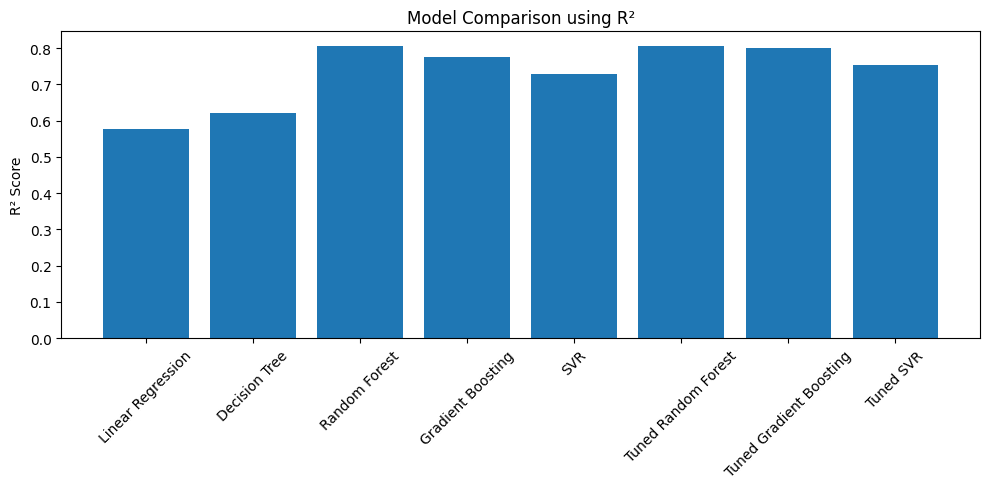

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(final_results["Model"], final_results["R2"])

plt.xticks(rotation=45)
plt.ylabel("R² Score")
plt.title("Model Comparison using R²")

plt.tight_layout()
plt.show()

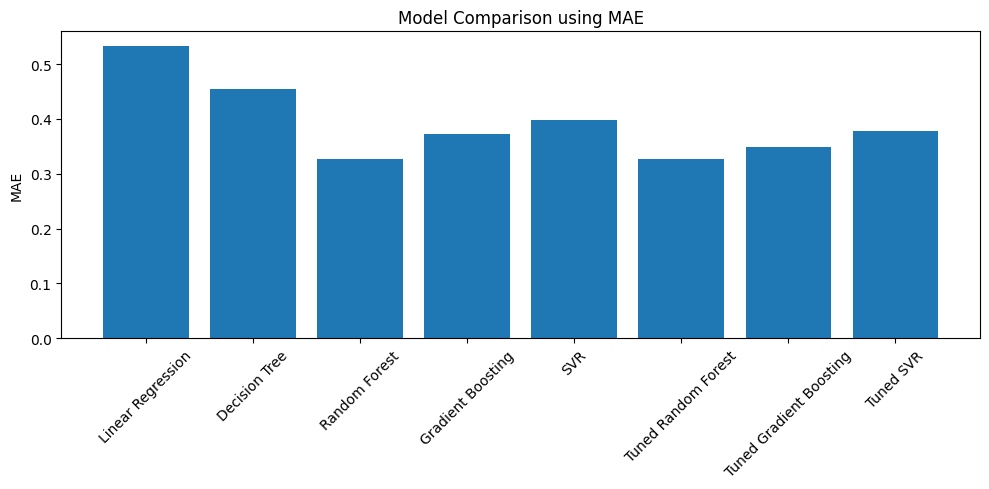

In [48]:
plt.figure(figsize=(10, 5))

plt.bar(final_results["Model"], final_results["MAE"])

plt.xticks(rotation=45)
plt.ylabel("MAE")
plt.title("Model Comparison using MAE")

plt.tight_layout()
plt.show()

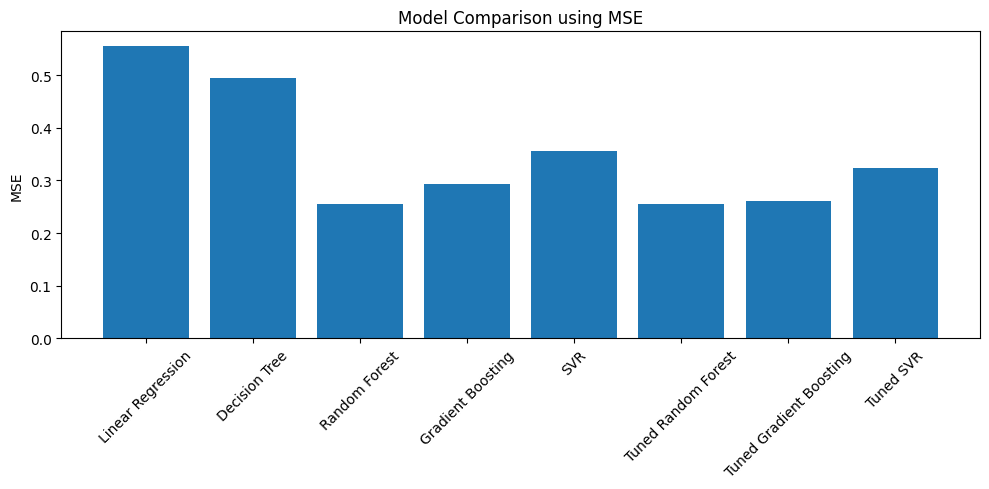

In [49]:
plt.figure(figsize=(10, 5))

plt.bar(final_results["Model"], final_results["MSE"])

plt.xticks(rotation=45)
plt.ylabel("MSE")
plt.title("Model Comparison using MSE")

plt.tight_layout()
plt.show()

Feature Importance

In [50]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
0,MedInc,0.526842
5,AveOccup,0.138143
6,Latitude,0.088633
7,Longitude,0.088177
1,HouseAge,0.054128
2,AveRooms,0.044249
4,Population,0.030494
3,AveBedrms,0.029334


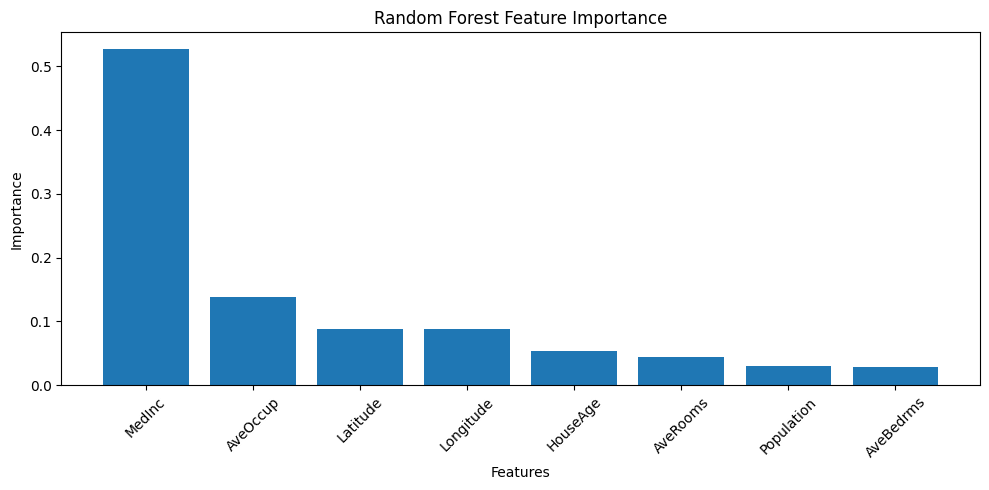

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

## Conclusion

In this assignment, the California Housing dataset was used to evaluate
different regression algorithms.

The following models were implemented:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Gradient Boosting Regressor
5. Support Vector Regressor

The models were evaluated using Mean Squared Error (MSE), Mean Absolute
Error (MAE), and R² score.

Five-fold cross-validation was also performed to obtain a more reliable
estimate of model performance. Hyperparameter tuning was performed using
GridSearchCV for selected models.

The final model should be selected based on the evaluation results,
cross-validation performance, and tuned model performance.

A higher R² score and lower MSE and MAE indicate better regression
performance.